# Image Classification with CNN

## Project description goes here

## 1. Load, process, validate data

### 1.1 Imports and renaming data folders

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os 
import tensorflow as tf
from tensorflow.keras import models, layers
from translate import translate 

# Change folder names from Italian to English 
data_path = "./data"

for italian_name, english_name in translate.items():
    old_path = os.path.join(data_path, italian_name)
    new_path = os.path.join(data_path, english_name)
    
    if os.path.exists(old_path) and not os.path.exists(new_path):
        os.rename(old_path, new_path)
        print(f"Renamed {italian_name} to {english_name}")

### 1.2 Load data and create training and validation sets

In [9]:
data_kwargs = {
    "directory": 'data',
    "validation_split": 0.2,
    "seed": 123,
    "image_size": (224, 224),
    "batch_size": 32,
    "crop_to_aspect_ratio": True,
}

# Create training set (80% of data)
train_ds = tf.keras.utils.image_dataset_from_directory(
    **data_kwargs,
    subset="training"
)

# Create validation set (20% of data)
val_ds = tf.keras.utils.image_dataset_from_directory(
    **data_kwargs,
    subset="validation"
)

Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.


### 1.3 Validate data

- Is every image in the correct folder?
- Are the classes balanced?
- Can each image be read by the computer?
- Are there duplicate images?


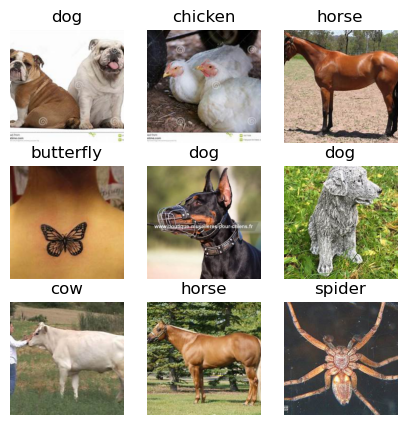

In [10]:
# Show a few images from the set 
for images, labels in train_ds.take(1):
    plt.figure(figsize=(5, 5))

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        
        # 3. Convert to uint8 for display if pixels are in [0, 255]
        # If your data is normalized to [0, 1], you can just use images[i].numpy()
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # 4. Show the class name (requires train_ds.class_names to be set)
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")
    
    plt.show()

In [11]:
# Count the occurences of each label 
labels = np.concatenate([y for x, y in train_ds], axis=0)
label_counts = np.bincount(labels)

for name, count in zip(train_ds.class_names, label_counts):
    print(f"{name:20} : {count}")

butterfly            : 1723
cat                  : 1345
chicken              : 2476
cow                  : 1484
dog                  : 3915
elephant             : 1152
horse                : 2087
sheep                : 1438
spider               : 3842
squirrel             : 1482


2026-02-26 18:51:04.853026: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


We notice that our dataset is imbalanced - our 'dog' and 'spider' classes have almost three times as many examples as our 'elephant' class

In [12]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
# Convert to a dictionary for Keras
class_weight_dict = dict(enumerate(class_weights))

### 1.4 Normalize the input

In [13]:
def normalize_img(image, label):
    '''Function scales pixels to [0, 1]'''
    return tf.cast(image, tf.float32) / 255.0, label

# Apply it to training and validation datasets
train_ds = train_ds.map(normalize_img)
val_ds = val_ds.map(normalize_img)